## Using Machine Learning to development a global coral bleaching predictor

#### Vocabulary
- S0
    - Latitude = ละติจูด (ตั้ง)
    - Longitude = ลองติจูด (นอน)
    - ClimSST = อุณภูมิพื้นผิวน้ำ
    - Windspeed = ความเร็วลม
    - Average_Bleaching  = เปอร์เซ็น การเกิด coral Bleaching
    - Ecoregion = เขตของเมือง
    - Realm
    - Ocean
    - Depth_m

- S1 อุณหภูมิ เคลวิล
    - Temperature_Kelvin
    - Temperature_Mean (celsius)
    - Temperature_Minimunm (celsius)
    - Temperature_Maximum (celsius)

- S2 การเปลี่ยนเเปลงของอุณภูมิผิวน้ำที่กำลังเพิ่มขึ้น Celsius
    - SSTA
    - SSTA_Mean
    - SSTA_Minimum
    - SSTA_Maximum

- S3 ความถี่ของการเปลี่ยนเเปลงอุณหภูมิผิวน้ำ 52 สัปดาห์
    - SSTA_Frequency
    - SSTA_FrequencyMax
    - SSTA_FrequencyMean

- S4 การเปลี่ยนเเปลงของอุณภูมิผิวน้ำที่กำลังเพิ่มขึ้น 12 สัปดาห์ Weeks
    - SSTA_DHW
    - SSTA_DHWMax
    - SSTA_DHWMean

- S5 (Thermal Stress Anomaly : Celsius) ความผิดปกติของความเรียดจากความร้อน
    - TSA
    - TSA_Minimum
    - TSA_Maximum
    - TSA_Mean

- S6 (Thermal Stress Anomaly : previous 52 weeks) ความถี่ของความผิดปกติความเครียดจากความร้อน TSA per time period
    - TSA_Frequency
    - TSA_FrequencyMax
    - TSA_FrequencyMean

- S7 (Thermal Stress Anomaly (TSA) Degree Heating Week (DWH) : Weeks)  ความผิดปกติความเครียดจากความร้อนเพิ่มสูงขึ้น 12 สัปดาห์ 
    - TSA_DHW 
    - TSA_DHWMAx
    - TSA_DHWMean

##

In [1]:
# loading packages
import numpy as np
import pandas as pd
import scipy.stats as ss
from string import ascii_letters
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# machine learning
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures , MinMaxScaler
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, BayesianRidge 
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score  , mean_absolute_percentage_error
from sklearn.preprocessing import scale
from sklearn.decomposition import PCA
from sklearn.utils import shuffle
from sklearn.cluster import KMeans

In [3]:
from scipy.cluster.hierarchy import linkage,dendrogram,cut_tree
from scipy.io import loadmat
from collections import defaultdict
from collections import Counter
from shapely.geometry import Point

In [4]:
df_old = pd.read_csv("C:\\Github\\Coral_Bleaching_Predictor\\Data\\dataset.csv" , na_values=['nd']) # old data
df_old

,ID,Latitude_Degrees,Longitude_Degrees,Ocean,Realm,Ecoregion,Country_Name,State_Island_Province,City_Town,City_Town_2,...,TSA_Maximum,TSA_Mean,TSA_Frequency,TSA_Frequency_Standard_Deviation,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean
0,97,-20.899833,149.407722,Pacific,Central Indo-Pacific,Southern Great Barrier Reef,Australia,Queensland,Keswick Island,NaN,...,2.40,-3.26,3.0,1.95,7.0,1.0,3.52,1.36,8.43,0.52
1,98,-20.893056,149.421000,Pacific,Central Indo-Pacific,Southern Great Barrier Reef,Australia,Queensland,Keswick Island,NaN,...,2.40,-3.26,3.0,1.95,7.0,1.0,3.52,1.36,8.43,0.52
2,116,-20.745806,149.472056,Pacific,Central Indo-Pacific,Southern Great Barrier Reef,Australia,Queensland,Wigton Island,Wigton Island Reef,...,2.34,-3.06,1.0,1.47,5.0,1.0,1.51,1.23,7.32,0.49
3,117,-20.737694,149.464944,Pacific,Central Indo-Pacific,Southern Great Barrier Reef,Australia,Queensland,Wigton Island,Wigton Island Reef,...,2.64,-3.01,2.0,1.31,5.0,1.0,2.36,0.97,6.86,0.36
4,142,-20.259361,148.814583,Pacific,Central Indo-Pacific,Central and northern Great Barrier Reef,Australia,Queensland,Mount Rooper,Daydream Island,...,2.81,-3.23,4.0,1.72,7.0,1.0,0.00,1.47,9.84,0.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9660,13073,13.935889,48.386417,Red Sea,Western Indo-Pacific,Gulf of Aden,Yemen,Shabwah Governorate,Bi'r Ali,Eemad,...,10.59,-1.86,1.0,2.30,11.0,2.0,2.63,2.57,20.95,1.08
9661,13074,13.935889,48.386417,Red Sea,Western Indo-Pacific,Gulf of Aden,Yemen,Shabwah Governorate,Bi'r Ali,Eemad,...,10.59,-1.86,1.0,2.30,11.0,2.0,2.63,2.57,20.95,1.08
9662,13075,14.817722,50.015250,Red Sea,Western Indo-Pacific,Gulf of Aden,Yemen,Hadhramaut Governorate,Al-Qurn,Eemad,...,10.51,-2.13,0.0,1.97,10.0,2.0,0.00,2.74,23.70,1.09
9663,13076,15.701611,42.391806,Red Sea,Western Indo-Pacific,South Red Sea,Yemen,Al Hudaydah Governorate,Jazirat Antufash,Seaem,...,2.52,-2.69,0.0,1.63,6.0,1.0,0.00,1.33,8.30,0.54


In [5]:
df_old[['Date', 'Temperature_Mean']]

,Date,Temperature_Mean
0,3/26/2016,298.17
1,3/26/2016,298.17
2,3/27/2016,298.34
3,3/27/2016,298.37
4,8/6/2017,298.47
...,...,...
9660,7/23/2008,300.68
9661,7/23/2008,300.68
9662,7/24/2008,300.49
9663,7/17/2008,301.97


In [6]:
df_old[['Date2']]

,Date2
0,20160326
1,20160326
2,20160327
3,20160327
4,20170806
...,...
9660,20080723
9661,20080723
9662,20080724
9663,20080717


In [7]:
df_old[['Ecoregion']]

,Ecoregion
0,Southern Great Barrier Reef
1,Southern Great Barrier Reef
2,Southern Great Barrier Reef
3,Southern Great Barrier Reef
4,Central and northern Great Barrier Reef
...,...
9660,Gulf of Aden
9661,Gulf of Aden
9662,Gulf of Aden
9663,South Red Sea


In [8]:
df_old[['ID']]

,ID
0,97
1,98
2,116
3,117
4,142
...,...
9660,13073
9661,13074
9662,13075
9663,13076


In [9]:
print(f"total number of rows and columns in the dataset: {len(df_old.columns)} columns, {len(df_old)} rows")

total number of rows and columns in the dataset: 48 columns, 9665 rows


In [10]:
#Check NAN Data and by what percentage
def nan_check(data):
    total = data.isnull().sum().sort_values(ascending=False)
    percent_1 = data.isnull().sum()/data.isnull().count()*100
    percent_2 = (np.round(percent_1, 1)).sort_values(ascending=False)
    missing_data = pd.concat([total, percent_2], axis=1, keys=['Total', '%'])
    return missing_data

In [11]:
nan_check(df_old)

,Total,%
City_Town_3,8728,90.3
City_Town_2,4943,51.1
City_Town,437,4.5
State_Island_Province,36,0.4
SSTA_Minimum,12,0.1
TSA_Minimum,5,0.1
SSTA_Frequency_Standard_Deviation,5,0.1
SSTA_FrequencyMax,5,0.1
SSTA_FrequencyMean,5,0.1
SSTA_DHW,5,0.1


In [12]:
nan_check(df_old[['SSTA_DHW', 'SSTA_DHWMax', 'SSTA_DHWMean']])

,Total,%
SSTA_DHW,5,0.1
SSTA_DHWMax,5,0.1
SSTA_DHWMean,5,0.1


In [14]:
def Cleaning_date_to_year(df):
    #Changing date to year
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df['Year'] = df['Date'].dt.year # New columns with only year 
    
    year_counts = df.groupby(['Year']).size()
    #print(year_counts)
    

    return df

df_Makedatetime = Cleaning_date_to_year(df_old)

In [ ]:
def Clean_data_newtechnique(df):
    df = df[df['Year'] > 2002]
    
    df['SSTA'] = pd.to_numeric(df['SSTA'], errors='coerce')
    df = df[df['SSTA'] > 0] # เป็นค่าที่ส่งผลกับ SSTA_Frequency เเละ อื่นๆ
    
    df = df.drop(columns=['City_Town_3', 'City_Town_2', 'City_Town', 'Date2'])

    df = df.rename(columns={"Country_Name": "Country", "Depth": "Depth_m", "Average_Bleaching": "Average_Bleaching_percent"})

    #Transforming column datatypes
    df['ClimSST'] = pd.to_numeric(df['ClimSST'],errors='coerce')
    df['Average_Bleaching_percent'] = pd.to_numeric(df['Average_Bleaching_percent'],errors='coerce')
    
    return df

In [15]:
df_Selected_feature_secondex = Clean_data_newtechnique(df_SecondExdatetime)

C:\Users\superuser\AppData\Local\Temp\ipykernel_6004\1829352832.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['SSTA'] = pd.to_numeric(df['SSTA'], errors='coerce')


In [16]:
df_Selected_feature_secondex.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6112 entries, 0 to 9664
Data columns (total 45 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   ID                                     6112 non-null   int64         
 1   Latitude_Degrees                       6112 non-null   float64       
 2   Longitude_Degrees                      6112 non-null   float64       
 3   Ocean                                  6112 non-null   object        
 4   Realm                                  6112 non-null   object        
 5   Ecoregion                              6112 non-null   object        
 6   Country                                6112 non-null   object        
 7   State_Island_Province                  6087 non-null   object        
 8   Date                                   6112 non-null   datetime64[ns]
 9   Depth_m                                6112 non-null   float64      

In [17]:
def feature_for_experiental_two(df, need_cols):
    List_cols = []
    cols_S1 = df[['Temperature_Kelvin', 'Temperature_Mean', 'Temperature_Minimum', 'Temperature_Maximum']]
    cols_S2 = df[['SSTA', 'SSTA_Mean', 'SSTA_Minimum', 'SSTA_Maximum']]
    cols_S3 = df[['SSTA_Frequency', 'SSTA_FrequencyMax', 'SSTA_FrequencyMean']]
    cols_S4 = df[['SSTA_DHW', 'SSTA_DHWMax', 'SSTA_DHWMean']]
    cols_S5 = df[['TSA', 'TSA_Minimum', 'TSA_Maximum', 'TSA_Mean']]
    cols_S6 = df[['TSA_Frequency', 'TSA_FrequencyMax', 'TSA_FrequencyMean']]
    cols_S7 = df[['TSA_DHW', 'TSA_DHWMax', 'TSA_DHWMean']]
    
      
    List_cols = [[cols_S1 , 'kelvin'] , [ cols_S2 , 'Celsius'] , [cols_S3, 'SSTA per time period0'] , [cols_S4, 'Weeks'] , [cols_S5, 'Celsius' ] , [cols_S6, 'TSA per time period'] , [cols_S7, 'Weeks']]
    print(f"Units is {List_cols[need_cols][1]}")
    
    return List_cols[need_cols]

In [18]:
def Select_data_some_datetime(df):

    # using data from 2003 to 2020
    df = df[df['Year'] > 2002]

    # Taking only SSTA > 0
    df['SSTA'] = pd.to_numeric(df['SSTA'], errors='coerce')
    df = df[df['SSTA'] > 0]
    
    df = df.drop(columns=['City_Town_3', 'City_Town_2', 'City_Town', 'Date2'])

    df = df.rename(columns={"Country_Name": "Country", "Depth": "Depth_m", "Average_Bleaching": "Average_Bleaching_percent"})

    #Transforming column datatypes
    df['ClimSST'] = pd.to_numeric(df['ClimSST'],errors='coerce')
    df['Average_Bleaching_percent'] = pd.to_numeric(df['Average_Bleaching_percent'],errors='coerce')


    df_numeric = df.select_dtypes(include=['number'])

    #Find highly correlated pairs
    corr_matrix = df_numeric.corr().abs()
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape),k=1).astype(bool))
    #print(upper_tri)
    to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.80)]
    
    df = df.drop(columns=to_drop)
    df = df.drop(df.select_dtypes(exclude=['number']).columns, axis=1)
    print(to_drop)
    print(f"Data make drop is : {len(to_drop)}")
    print(f"collumns have : {len(df.columns)}")
    print(f"Dataset have : {len(df)}")
    
    return df


df_selected_feature_fristEx = Select_data_some_datetime(df_fristExdatetime)

['Temperature_Minimum', 'Temperature_Kelvin_Standard_Deviation', 'SSTA_FrequencyMax', 'SSTA_FrequencyMean', 'SSTA_DHW_Standard_Deviation', 'SSTA_DHWMax', 'SSTA_DHWMean', 'TSA', 'TSA_Standard_Deviation', 'TSA_Minimum', 'TSA_Mean', 'TSA_FrequencyMax', 'TSA_DHW_Standard_Deviation', 'TSA_DHWMax', 'TSA_DHWMean']
Data make drop is : 15
collumns have : 24
Dataset have : 6112


C:\Users\superuser\AppData\Local\Temp\ipykernel_6004\2468718535.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['SSTA'] = pd.to_numeric(df['SSTA'], errors='coerce')


In [19]:
nan_check(df_selected_feature_fristEx)

,Total,%
SSTA_Minimum,3,0.0
ID,0,0.0
Latitude_Degrees,0,0.0
TSA_DHW,0,0.0
TSA_FrequencyMean,0,0.0
TSA_Frequency_Standard_Deviation,0,0.0
TSA_Frequency,0,0.0
TSA_Maximum,0,0.0
SSTA_DHW,0,0.0
SSTA_Frequency_Standard_Deviation,0,0.0


In [20]:
#Fill NA into the data object
df_fillnafristEx = df_selected_feature_fristEx.fillna(method ='ffill')
df_fillnasecondEx = df_Selected_feature_secondex.fillna(method='ffill')
df_fillnathirdEx = df_Selected_feature_secondex.fillna(method='ffill')

C:\Users\superuser\AppData\Local\Temp\ipykernel_6004\4074345512.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_fillnafristEx = df_selected_feature_fristEx.fillna(method ='ffill')
C:\Users\superuser\AppData\Local\Temp\ipykernel_6004\4074345512.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_fillnasecondEx = df_Selected_feature_secondex.fillna(method='ffill')
C:\Users\superuser\AppData\Local\Temp\ipykernel_6004\4074345512.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_fillnathirdEx = df_Selected_feature_secondex.fillna(method='ffill')


In [21]:
print(f"total number of rows and columns in the dataset: {len(df_fillnafristEx.columns)} columns, {len(df_fillnafristEx)} rows") # have year columns 

total number of rows and columns in the dataset: 24 columns, 6112 rows


In [22]:
print(f"total number of rows and columns in the dataset: {len(df_fillnasecondEx.columns)} columns, {len(df_fillnasecondEx)} rows") # have year columns 

total number of rows and columns in the dataset: 45 columns, 6112 rows


##

## -----------------------
## Correlation Visualize
## -----------------------

In [23]:
def PLOT_CORRELATION(df):
    corr = df.corr()
    # ตัวอย่าง: สมมุติ corr คือ correlation matrix ของ DataFrame
    plt.figure(figsize=(8, 6))
    sns.set_theme(style="white")  # ธีมพื้นขาว สบายตา
    ax = sns.heatmap(
        corr.round(2),
        annot=True,             # แสดงค่าตัวเลขในช่อง
        fmt=".2f",              # ทศนิยม 2 ตำแหน่ง
        cmap="Spectral",        # โทนสี (แนะนำ: 'coolwarm', 'RdYlBu', 'Spectral')
        vmin=-1, vmax=1,        # กำหนดขอบของค่า correlation
        center=0,               # ให้สีตรงกลางเท่ากับ 0
        linewidths=0.6,         # เส้นแบ่งแต่ละช่อง
        square=True,            # ทำให้เป็นสี่เหลี่ยมจัตุรัส
        cbar_kws={'shrink': 0.8, 'aspect': 20, 'label': 'Correlation'}  # ปรับ bar ด้านข้าง
    )

    # เพิ่มความสวยงามโดยรวม
    plt.style.use("seaborn-v0_8-paper")
    plt.title("Correlation Heatmap", fontsize=16, fontweight='bold', pad=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [24]:
df_fillnafristEx.corr()['Average_Bleaching_percent'].sort_values(ascending=False)

Average_Bleaching_percent            1.000000
SSTA_DHW                             0.176013
TSA_DHW                              0.174344
SSTA_Frequency                       0.136499
TSA_Frequency                        0.116205
SSTA                                 0.061674
Windspeed                            0.059772
SSTA_Minimum                         0.047890
ClimSST                              0.046032
Temperature_Kelvin                   0.041216
Year                                 0.034170
Depth_m                              0.027032
Temperature_Mean                     0.021123
Temperature_Maximum                  0.014305
TSA_Maximum                          0.013345
Latitude_Degrees                    -0.006710
SSTA_Maximum                        -0.012118
TSA_FrequencyMean                   -0.024203
SSTA_Standard_Deviation             -0.039344
SSTA_Frequency_Standard_Deviation   -0.049784
TSA_Frequency_Standard_Deviation    -0.056946
ID                                

#### SSTA_Mean don't have data becuase columns zeroes all

In [25]:
df_fillnafristEx.select_dtypes(exclude=['number']).columns

Index([], dtype='object')

In [26]:
print(f"total number of rows and columns in the dataset: {len(df_fillnafristEx.columns)} columns, {len(df_fillnafristEx)} rows") # have year columns 
print(f"Columns does't have numdic : {df_fillnafristEx.select_dtypes(exclude=['object']).columns}")
df_fristEx_model = df_fillnafristEx.copy()

total number of rows and columns in the dataset: 24 columns, 6112 rows
Columns does't have numdic : Index(['ID', 'Latitude_Degrees', 'Longitude_Degrees', 'Depth_m',
       'Average_Bleaching_percent', 'ClimSST', 'Temperature_Kelvin',
       'Temperature_Mean', 'Temperature_Maximum', 'Windspeed', 'SSTA',
       'SSTA_Standard_Deviation', 'SSTA_Mean', 'SSTA_Minimum', 'SSTA_Maximum',
       'SSTA_Frequency', 'SSTA_Frequency_Standard_Deviation', 'SSTA_DHW',
       'TSA_Maximum', 'TSA_Frequency', 'TSA_Frequency_Standard_Deviation',
       'TSA_FrequencyMean', 'TSA_DHW', 'Year'],
      dtype='object')


In [27]:
print(f"total number of rows and columns in the dataset: {len(df_fillnasecondEx.columns)} columns, {len(df_fillnasecondEx)} rows") # have year columns 
print(f"Collumns does't have numeric : {df_fillnasecondEx.select_dtypes(exclude=['object']).columns}")
df_secondEX_model = df_fillnasecondEx.copy() # Feature for training model second Experimental

total number of rows and columns in the dataset: 45 columns, 6112 rows
Collumns does't have numeric : Index(['ID', 'Latitude_Degrees', 'Longitude_Degrees', 'Date', 'Depth_m',
       'Average_Bleaching_percent', 'ClimSST', 'Temperature_Kelvin',
       'Temperature_Mean', 'Temperature_Minimum', 'Temperature_Maximum',
       'Temperature_Kelvin_Standard_Deviation', 'Windspeed', 'SSTA',
       'SSTA_Standard_Deviation', 'SSTA_Mean', 'SSTA_Minimum', 'SSTA_Maximum',
       'SSTA_Frequency', 'SSTA_Frequency_Standard_Deviation',
       'SSTA_FrequencyMax', 'SSTA_FrequencyMean', 'SSTA_DHW',
       'SSTA_DHW_Standard_Deviation', 'SSTA_DHWMax', 'SSTA_DHWMean', 'TSA',
       'TSA_Standard_Deviation', 'TSA_Minimum', 'TSA_Maximum', 'TSA_Mean',
       'TSA_Frequency', 'TSA_Frequency_Standard_Deviation', 'TSA_FrequencyMax',
       'TSA_FrequencyMean', 'TSA_DHW', 'TSA_DHW_Standard_Deviation',
       'TSA_DHWMax', 'TSA_DHWMean', 'Year'],
      dtype='object')


In [28]:
print(f"total number of rows and columns in the dataset: {len(df_fillnathirdEx.columns)} columns, {len(df_fillnathirdEx)} rows") # have year columns 
print(f"Collumns does't have numeric : {df_fillnathirdEx.select_dtypes(exclude=['object']).columns}")
df_thirdEX_model = df_fillnathirdEx.select_dtypes(exclude=['object']).copy() # Feature for training model second Experimental

total number of rows and columns in the dataset: 45 columns, 6112 rows
Collumns does't have numeric : Index(['ID', 'Latitude_Degrees', 'Longitude_Degrees', 'Date', 'Depth_m',
       'Average_Bleaching_percent', 'ClimSST', 'Temperature_Kelvin',
       'Temperature_Mean', 'Temperature_Minimum', 'Temperature_Maximum',
       'Temperature_Kelvin_Standard_Deviation', 'Windspeed', 'SSTA',
       'SSTA_Standard_Deviation', 'SSTA_Mean', 'SSTA_Minimum', 'SSTA_Maximum',
       'SSTA_Frequency', 'SSTA_Frequency_Standard_Deviation',
       'SSTA_FrequencyMax', 'SSTA_FrequencyMean', 'SSTA_DHW',
       'SSTA_DHW_Standard_Deviation', 'SSTA_DHWMax', 'SSTA_DHWMean', 'TSA',
       'TSA_Standard_Deviation', 'TSA_Minimum', 'TSA_Maximum', 'TSA_Mean',
       'TSA_Frequency', 'TSA_Frequency_Standard_Deviation', 'TSA_FrequencyMax',
       'TSA_FrequencyMean', 'TSA_DHW', 'TSA_DHW_Standard_Deviation',
       'TSA_DHWMax', 'TSA_DHWMean', 'Year'],
      dtype='object')


In [29]:
nan_check(df_secondEX_model)

,Total,%
ID,0,0.0
SSTA_Frequency,0,0.0
SSTA_FrequencyMax,0,0.0
SSTA_FrequencyMean,0,0.0
SSTA_DHW,0,0.0
SSTA_DHW_Standard_Deviation,0,0.0
SSTA_DHWMax,0,0.0
SSTA_DHWMean,0,0.0
TSA,0,0.0
TSA_Standard_Deviation,0,0.0


In [30]:
nan_check(df_fristEx_model)

,Total,%
ID,0,0.0
Latitude_Degrees,0,0.0
TSA_DHW,0,0.0
TSA_FrequencyMean,0,0.0
TSA_Frequency_Standard_Deviation,0,0.0
TSA_Frequency,0,0.0
TSA_Maximum,0,0.0
SSTA_DHW,0,0.0
SSTA_Frequency_Standard_Deviation,0,0.0
SSTA_Frequency,0,0.0


In [31]:
nan_check(df_thirdEX_model)

,Total,%
ID,0,0.0
Latitude_Degrees,0,0.0
SSTA_DHW,0,0.0
SSTA_DHW_Standard_Deviation,0,0.0
SSTA_DHWMax,0,0.0
SSTA_DHWMean,0,0.0
TSA,0,0.0
TSA_Standard_Deviation,0,0.0
TSA_Minimum,0,0.0
TSA_Maximum,0,0.0


In [32]:
# Frist experimental , if correlation more than zero
df_positive_corr = df_fillnafristEx.corr()['Average_Bleaching_percent'][df_fillnafristEx.corr()['Average_Bleaching_percent'] > 0].sort_values(ascending=False)

In [33]:
df_positive_corr

Average_Bleaching_percent    1.000000
SSTA_DHW                     0.176013
TSA_DHW                      0.174344
SSTA_Frequency               0.136499
TSA_Frequency                0.116205
SSTA                         0.061674
Windspeed                    0.059772
SSTA_Minimum                 0.047890
ClimSST                      0.046032
Temperature_Kelvin           0.041216
Year                         0.034170
Depth_m                      0.027032
Temperature_Mean             0.021123
Temperature_Maximum          0.014305
TSA_Maximum                  0.013345
Name: Average_Bleaching_percent, dtype: float64

##

# -----------------------------------------
## Data analysis and look for insight data 
# -----------------------------------------

In [34]:
def Histrogram_data(df,col):
    plt.hist(df[[col]], density=True, bins=30, color='skyblue', edgecolor='black')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.title(f'Histrogram of {col}')
    plt.show()
    
    Hight = []
    Low = []
    zero = 0
    
    for i in df[col]:
        if i == 0:
            text = "Data not values"
            zero += 1
        elif i >= 30:
            Hight.append(i)
        else:
            Low.append(i)
    if len(Hight) != 0:
        print(f"columns have dataset : {len(df[col])}")
        print(f"columns have maximum data : {len(Hight)} is {Hight[0]} from more than >30%")
        print(f"columns have minimum data : {len(Low)} is {Low[0]} from less than <30%")
    else:
        print(f"{text} and count = {zero}")

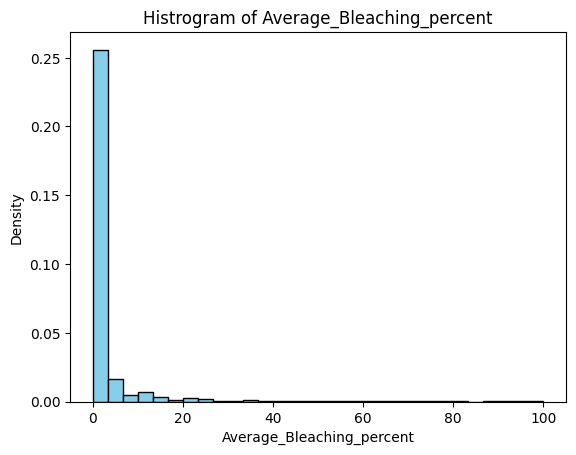

columns have dataset : 6112
columns have maximum data : 151 is 33.75 from more than >30%
columns have minimum data : 2047 is 6.25 from less than <30%


In [35]:
Histrogram_data(df_secondEX_model, 'Average_Bleaching_percent')

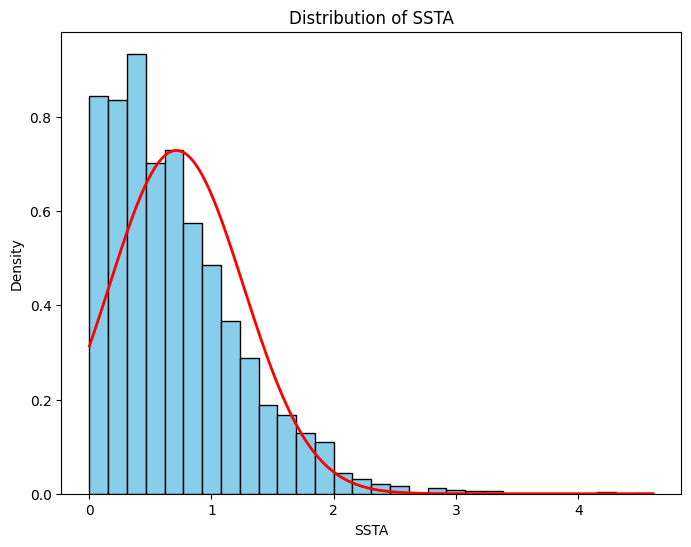

In [36]:
def plotting_distribution(data, columns):
    for col in columns:
        norm_fit = ss.norm.fit(data[col])
        datasortvalues = data[col].sort_values()
        plt.figure(figsize=(8,6))
        plt.hist(data[[col]], density=True, bins=30, color='skyblue', edgecolor='black')
        plt.plot(datasortvalues, ss.norm.pdf(datasortvalues, *norm_fit), color='red', linewidth=2)
        plt.xlabel(col)
        plt.ylabel('Density')
        plt.title(f'Distribution of {col}')
        plt.show()


plotting_distribution(df_fillnafristEx, df_fillnafristEx[['SSTA']])

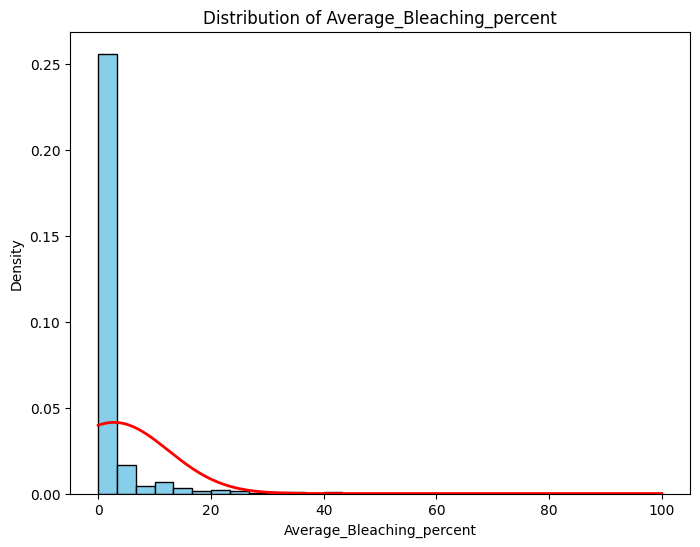

In [37]:
plotting_distribution(df_secondEX_model, df_secondEX_model[['Average_Bleaching_percent']])

In [38]:
def PLOT_feature_with_target(df,feature_cals,target_col):
    X = df[feature_cals]
    y = df[target_col]
    
    plt.figure(figsize=(6,4))
    plt.scatter(X, y, color='white', edgecolors='black', alpha=0.3)  # ขอบสีดำ (ช่วยให้เห็นชัด)
    
    plt.xlabel(feature_cals)
    plt.ylabel(target_col)
    plt.title(f'{feature_cals} vs {target_col}')
    
    plt.show()

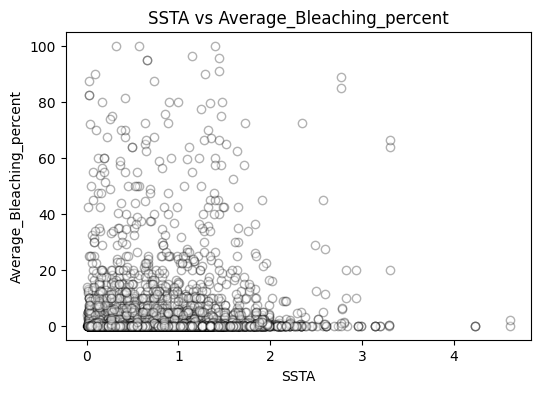

In [39]:
PLOT_feature_with_target(df_secondEX_model,'SSTA','Average_Bleaching_percent')

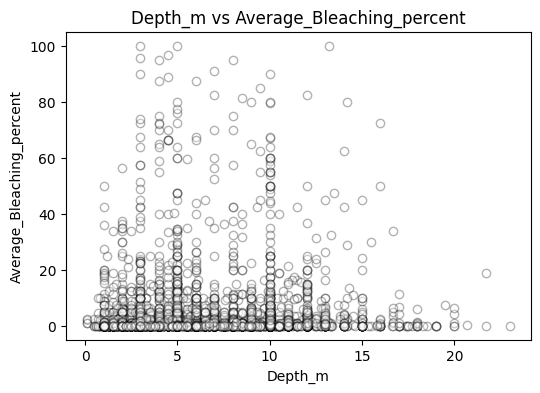

In [40]:
PLOT_feature_with_target(df_secondEX_model,'Depth_m','Average_Bleaching_percent')

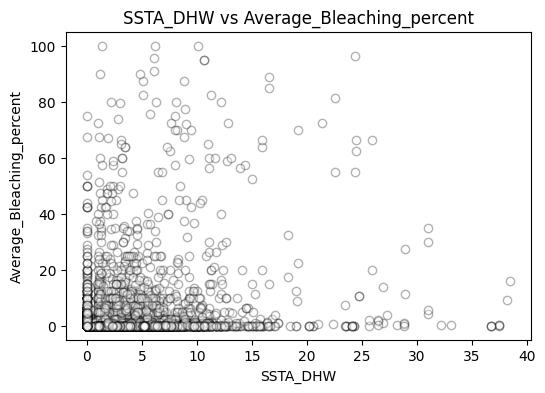

In [41]:
PLOT_feature_with_target(df_secondEX_model,'SSTA_DHW','Average_Bleaching_percent')

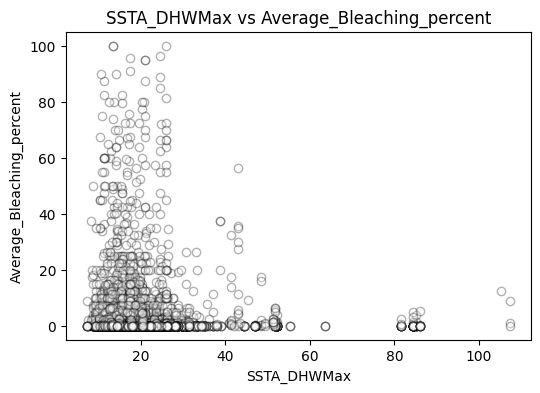

In [42]:
PLOT_feature_with_target(df_secondEX_model,'SSTA_DHWMax','Average_Bleaching_percent')

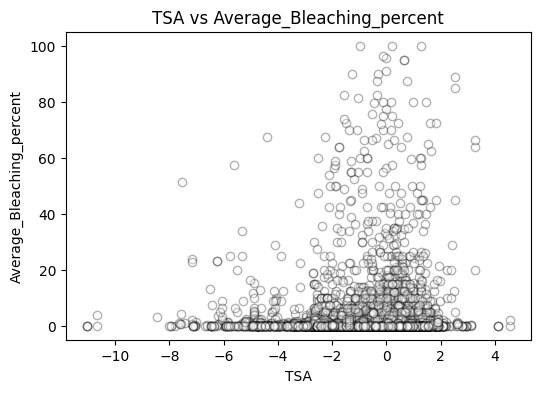

In [43]:
PLOT_feature_with_target(df_secondEX_model,'TSA','Average_Bleaching_percent')

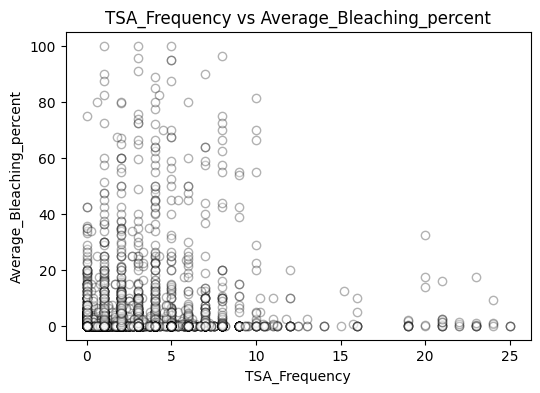

In [44]:
PLOT_feature_with_target(df_secondEX_model,'TSA_Frequency','Average_Bleaching_percent')

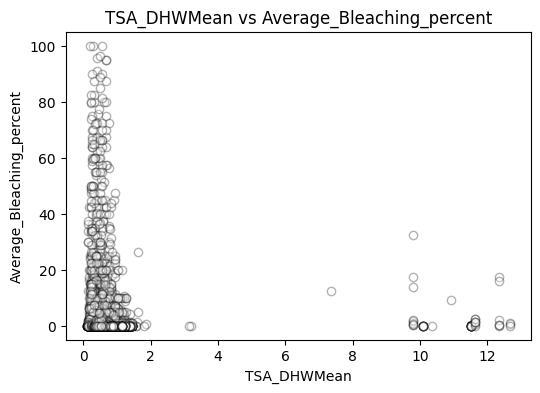

In [45]:
PLOT_feature_with_target(df_secondEX_model,'TSA_DHWMean','Average_Bleaching_percent')

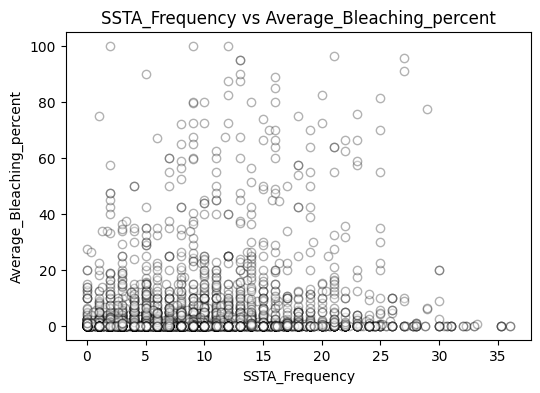

In [46]:
PLOT_feature_with_target(df_secondEX_model,'SSTA_Frequency','Average_Bleaching_percent')

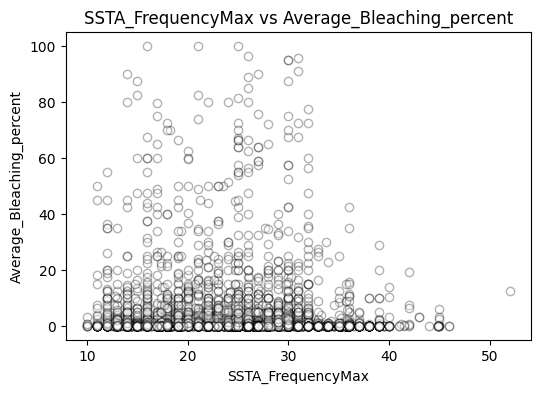

In [47]:
PLOT_feature_with_target(df_secondEX_model,'SSTA_FrequencyMax','Average_Bleaching_percent')

In [48]:
def Description(df):
    return df.describe()

In [49]:
Description(df_secondEX_model)

,ID,Latitude_Degrees,Longitude_Degrees,Date,Depth_m,Average_Bleaching_percent,ClimSST,Temperature_Kelvin,Temperature_Mean,Temperature_Minimum,...,TSA_Mean,TSA_Frequency,TSA_Frequency_Standard_Deviation,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean,Year
count,6112.000000,6112.000000,6112.000000,6112,6112.000000,6112.000000,6112.000000,6112.000000,6112.000000,6112.000000,...,6112.000000,6112.000000,6112.000000,6112.000000,6112.000000,6112.000000,6112.000000,6112.000000,6112.000000,6112.000000
mean,8062.540740,4.507037,58.370658,2010-09-19 09:06:21.675392768,6.471188,2.795220,293.849604,301.619961,300.495139,295.967369,...,-1.774442,2.227388,1.888265,8.628250,1.151686,1.060179,1.466989,10.876757,0.589154,2010.180301
min,97.000000,-28.162528,-179.859361,2003-01-23 00:00:00,0.100000,0.000000,262.150000,292.030000,294.300000,284.540000,...,-7.460000,0.000000,0.680000,3.000000,0.000000,0.000000,0.480000,2.590000,0.110000,2003.000000
25%,5726.250000,-8.475972,-38.671806,2006-12-02 00:00:00,4.000000,0.000000,297.910000,300.550000,299.740000,294.730000,...,-2.305000,0.000000,1.386250,6.000000,0.666667,0.000000,1.001250,7.550000,0.330000,2006.000000
50%,8291.500000,6.169861,104.126583,2010-07-28 00:00:00,6.000000,0.000000,300.810000,302.110000,300.896667,297.080000,...,-1.430000,1.000000,1.700000,8.000000,1.000000,0.000000,1.270000,9.710000,0.430000,2010.000000
75%,10627.500000,17.901861,123.379028,2014-07-27 06:00:00,10.000000,1.000000,302.150000,303.060000,301.810000,297.820000,...,-1.120000,3.000000,2.230000,10.000000,1.000000,1.120000,1.712500,12.850000,0.640000,2014.000000
max,13077.000000,34.098056,179.945333,2017-12-20 00:00:00,23.000000,100.000000,304.390000,306.800000,303.520000,300.350000,...,0.000000,25.000000,13.570000,52.000000,20.000000,37.680000,15.210000,63.470000,12.660000,2017.000000
std,3108.680297,15.746898,97.062979,NaN,3.467763,9.634113,15.068575,2.091429,1.734012,2.805761,...,1.067553,2.871312,0.724174,4.100404,1.782256,2.778678,1.132608,5.248742,0.987807,4.263251


In [50]:
def stats_summary(df , cols):
    desc = df[cols].describe().T
    desc["skew"] = df[cols].skew()
    desc["kurtosis"] = df[cols].kurtosis()
    return desc

In [51]:
stats_summary(df_secondEX_model , 'SSTA')

count       6112.000000
mean           0.712972
std            0.547437
min            0.002500
25%            0.300000
50%            0.600000
75%            1.000000
max            4.610000
skew           1.321043
kurtosis       2.888087
Name: SSTA, dtype: float64

In [52]:
def distribution_check(df , column):
    result = {}
    result[column] = {
            "min": df[column].min(),
            "max": df[column].max(),
            "outlier_count": ((df[column] < df[column].quantile(0.01)) |
                              (df[column] > df[column].quantile(0.99))).sum(),
            "lower_out" : df[column].quantile(0.01),
            "upper_out" : df[column].quantile(0.99)
            
        }
    return result

In [53]:
print(distribution_check(df_secondEX_model , 'SSTA'))
print(distribution_check(df_secondEX_model, 'Average_Bleaching_percent'))
print(distribution_check(df_secondEX_model, 'Depth_m'))
print(distribution_check(df_secondEX_model, 'SSTA_DHW'))

{'SSTA': {'min': 0.0025, 'max': 4.61, 'outlier_count': 122, 'lower_out': 0.02, 'upper_out': 2.34}}
{'Average_Bleaching_percent': {'min': 0.0, 'max': 100.0, 'outlier_count': 61, 'lower_out': 0.0, 'upper_out': 57.5}}
{'Depth_m': {'min': 0.1, 'max': 23.0, 'outlier_count': 83, 'lower_out': 1.0, 'upper_out': 15.8}}
{'SSTA_DHW': {'min': 0.0, 'max': 38.45, 'outlier_count': 61, 'lower_out': 0.0, 'upper_out': 19.04}}


##

#### Average_Bleaching_percent is zero and not zero

In [54]:
percent_zero = df_secondEX_model[df_secondEX_model['Average_Bleaching_percent'] == 0]
percent_zero.describe()

,ID,Latitude_Degrees,Longitude_Degrees,Date,Depth_m,Average_Bleaching_percent,ClimSST,Temperature_Kelvin,Temperature_Mean,Temperature_Minimum,...,TSA_Mean,TSA_Frequency,TSA_Frequency_Standard_Deviation,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean,Year
count,3914.000000,3914.000000,3914.000000,3914,3914.000000,3914.0,3914.000000,3914.000000,3914.000000,3914.000000,...,3914.000000,3914.000000,3914.000000,3914.000000,3914.000000,3914.000000,3914.000000,3914.000000,3914.000000,3914.000000
mean,8345.022228,5.771886,63.199160,2010-08-15 13:55:53.500255744,6.297420,0.0,293.001055,301.636618,300.521064,295.937110,...,-1.782338,2.132015,1.912794,8.740476,1.154152,0.871293,1.458039,10.887998,0.576150,2010.086357
min,183.000000,-28.162528,-179.494889,2003-01-23 00:00:00,0.500000,0.0,262.150000,292.030000,294.300000,284.540000,...,-5.696000,0.000000,0.680000,3.000000,0.000000,0.000000,0.480000,3.410000,0.110000,2003.000000
25%,6070.250000,-5.768229,34.521000,2006-12-08 00:00:00,3.500000,0.0,297.460000,300.570000,299.742500,294.747500,...,-2.285000,0.000000,1.420000,6.000000,1.000000,0.000000,1.010000,7.620000,0.330000,2006.000000
50%,8595.500000,6.076417,104.124431,2010-06-16 00:00:00,6.000000,0.0,300.820000,302.090000,300.900000,297.113750,...,-1.430000,1.000000,1.755000,8.000000,1.000000,0.000000,1.280000,9.820000,0.440000,2010.000000
75%,10731.750000,18.369111,121.263701,2014-04-29 06:00:00,9.400000,0.0,302.160000,303.030000,301.840000,297.880000,...,-1.120000,3.000000,2.285000,10.000000,1.000000,1.030000,1.716667,12.880000,0.640000,2014.000000
max,13077.000000,34.098056,179.945333,2017-12-20 00:00:00,23.000000,0.0,304.390000,305.850000,303.520000,300.350000,...,0.000000,25.000000,6.910000,31.000000,20.000000,36.310000,13.930000,49.240000,12.660000,2017.000000
std,2877.461634,15.334163,92.419328,NaN,3.381625,0.0,15.815180,2.017212,1.765553,2.926138,...,1.098337,2.708844,0.706708,3.978513,1.582027,2.312050,1.018564,5.022312,0.867169,4.210073


In [55]:
percent_Notzero = df_secondEX_model[df_secondEX_model['Average_Bleaching_percent'] != 0]
Description(percent_Notzero)

,ID,Latitude_Degrees,Longitude_Degrees,Date,Depth_m,Average_Bleaching_percent,ClimSST,Temperature_Kelvin,Temperature_Mean,Temperature_Minimum,...,TSA_Mean,TSA_Frequency,TSA_Frequency_Standard_Deviation,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean,Year
count,2198.000000,2198.000000,2198.000000,2198,2198.000000,2198.000000,2198.000000,2198.000000,2198.000000,2198.000000,...,2198.000000,2198.000000,2198.000000,2198.000000,2198.000000,2198.000000,2198.000000,2198.000000,2198.000000,2198.000000
mean,7559.523203,2.254708,49.772498,2010-11-20 08:18:33.739763456,6.780619,7.772695,295.360623,301.590299,300.448975,296.021252,...,-1.760382,2.397220,1.844587,8.428409,1.147294,1.396529,1.482927,10.856739,0.612310,2010.347589
min,97.000000,-28.109167,-179.859361,2003-02-16 00:00:00,0.100000,0.010000,262.150000,292.660000,294.710000,284.540000,...,-7.460000,0.000000,0.680000,3.000000,0.000000,0.000000,0.490000,2.590000,0.130000,2003.000000
25%,4687.250000,-16.241667,-69.072042,2006-11-17 12:00:00,4.000000,0.750000,298.660000,300.510000,299.740000,294.730000,...,-2.440000,0.000000,1.370000,6.000000,0.000000,0.000000,1.000000,7.360000,0.300000,2006.000000
50%,7938.500000,6.393639,104.141125,2010-09-06 12:00:00,6.000000,2.250000,300.770000,302.130000,300.890000,297.037500,...,-1.430000,1.500000,1.630000,7.000000,1.000000,0.000000,1.250000,9.520000,0.430000,2010.000000
75%,10416.500000,15.981111,125.120556,2014-11-11 18:00:00,10.000000,7.000000,302.100000,303.139500,301.730000,297.770000,...,-1.120000,3.333333,2.110000,9.500000,1.000000,1.380000,1.651500,12.470000,0.640000,2014.000000
max,13052.000000,34.056111,179.943833,2017-12-20 00:00:00,21.700000,100.000000,304.010000,306.800000,303.240000,299.880000,...,-0.010000,24.000000,13.570000,52.000000,20.000000,37.680000,15.210000,63.470000,12.660000,2017.000000
std,3426.102480,16.217280,104.293593,NaN,3.596122,14.814317,13.510389,2.217610,1.675781,2.577289,...,1.010509,3.133342,0.752462,4.302613,2.092278,3.432011,1.311462,5.630575,1.172151,4.352286


In [56]:
print(f"zero have : { ((df_secondEX_model['Average_Bleaching_percent'] == 0).sum())}")
print(f"Not have zero : {((df_secondEX_model['Average_Bleaching_percent'] != 0).sum())}")

zero have : 3914
Not have zero : 2198


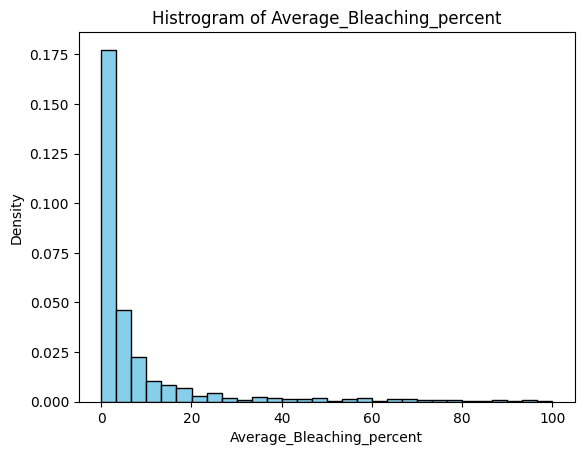

columns have dataset : 2198
columns have maximum data : 151 is 33.75 from more than >30%
columns have minimum data : 2047 is 6.25 from less than <30%


In [57]:
Histrogram_data(percent_Notzero, 'Average_Bleaching_percent')

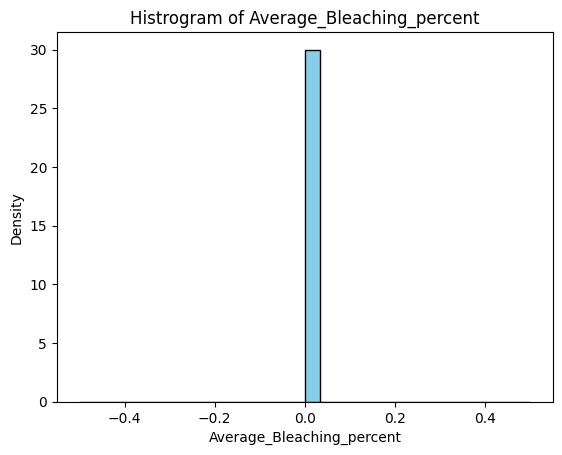

Data not values and count = 3914


In [58]:
Histrogram_data(percent_zero,'Average_Bleaching_percent')

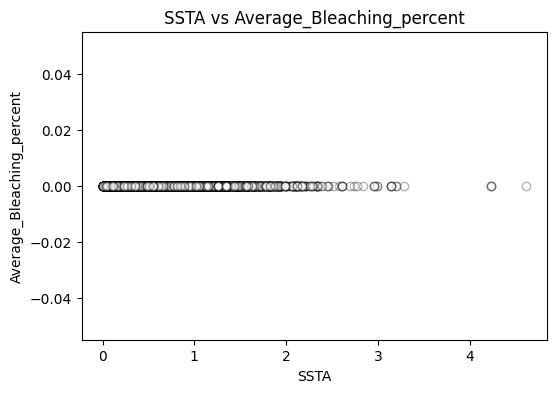

In [59]:
PLOT_feature_with_target(percent_zero,'SSTA','Average_Bleaching_percent')

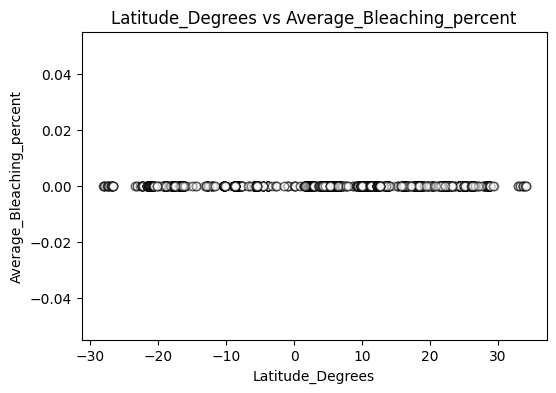

In [60]:
PLOT_feature_with_target(percent_zero,'Latitude_Degrees','Average_Bleaching_percent')

##

##

#### Correaltion Ploting

In [61]:
def PLOT_CORRELATION(df):
    df_corr = df.select_dtypes(exclude=['object'])
    
    corr = df_corr.corr()
    # ตัวอย่าง: สมมุติ corr คือ correlation matrix ของ DataFrame
    plt.figure(figsize=(12, 10))
    sns.set_theme(style="white")  # ธีมพื้นขาว สบายตา
    ax = sns.heatmap(
        corr.round(2),
        #annot=True,             # แสดงค่าตัวเลขในช่อง
        fmt=".2f",              # ทศนิยม 2 ตำแหน่ง
        cmap="Spectral",        # โทนสี (แนะนำ: 'coolwarm', 'RdYlBu', 'Spectral')
        vmin=-1, vmax=1,        # กำหนดขอบของค่า correlation
        center=0,               # ให้สีตรงกลางเท่ากับ 0
        linewidths=0.6,         # เส้นแบ่งแต่ละช่อง
        square=True,            # ทำให้เป็นสี่เหลี่ยมจัตุรัส
        cbar_kws={'shrink': 0.8, 'aspect': 20, 'label': 'Correlation'}  # ปรับ bar ด้านข้าง
    )

    # เพิ่มความสวยงามโดยรวม
    plt.style.use("seaborn-v0_8-paper")
    plt.title("Correlation Heatmap", fontsize=16, fontweight='bold', pad=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [62]:
def Linear_correlation(df):
    df_corr = df.select_dtypes(exclude=['object'])

    corr_matrix = df_corr.corr()  # ✅ สำคัญมาก

    # สร้าง mask เพื่อซ่อนครึ่งบน
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    plt.figure(figsize=(12,10))

    sns.heatmap(
        corr_matrix,
        mask=mask,
        #annot=True,
        fmt=".2f",
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        center=0,
        square=True,
        linewidths=.5,
        cbar_kws={"shrink": .8}
    )

    plt.title("Linear Correlations Between all Parameters", pad=20)

    plt.xticks(rotation=90)
    plt.yticks(rotation=0)

    plt.show()

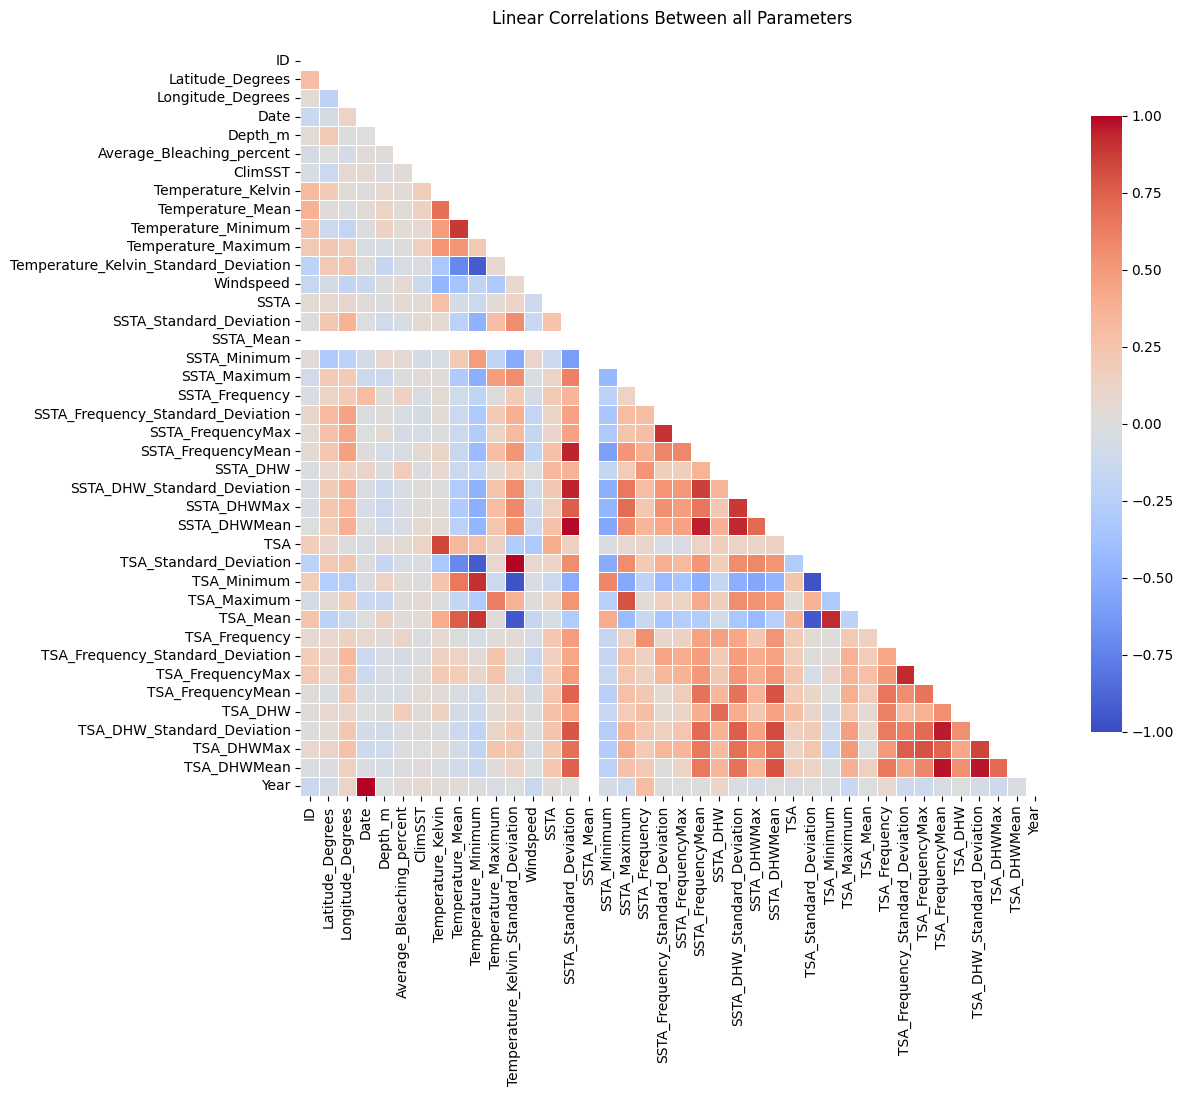

In [63]:
Linear_correlation(df_secondEX_model)

##

##

# -----------------
## Model predictive
# -----------------

In [64]:
def PLOTING_RESULT(pred,actual):
    y_test = actual.ravel()
    y_test_pred = pred.ravel()

    plt.figure(figsize=(10,6))

    plt.scatter(range(len(y_test)), y_test, 
                color='red', alpha=1, label='Actual values')

    plt.scatter(range(len(y_test_pred)), y_test_pred, 
                color='green', alpha=0.8, label='Predicted Values')

    plt.xlabel('Sample Index')
    plt.ylabel('Bleaching Percent')
    plt.title('Random Forest Prediction vs Actual Values')

    plt.legend()
    plt.show()

In [65]:
def Metric_result(model , X_train , X_test , y_train , y_test):
    print(f"Score on training data: {(model.score(X_train, y_train)).round(3)}") # score from training
    pred = model.predict(X_test)


    test_mse = mean_squared_error(y_test, pred) # Mean_Squaed_error
    print("Test MSE:", test_mse.round(3))


    test_rmse = np.sqrt(mean_squared_error(y_test, pred)) # Root_mean_squared_error
    print(f"Test RMSE : {test_rmse.round(3)}")

    test_r2 = r2_score(y_test, pred) # R2_squared
    print(f"Test R2 Score : {test_r2.round(3)}")

    test_mae = mean_absolute_error(y_test, pred) # Mean_Absolute_error
    print(f"Mean Absolute Error : {test_mae.round(3)}")


In [66]:
def RESULT_K_FOLD(results,cv):
    r2 = results['test_r2']
    rmse = np.sqrt(-results['test_neg_mean_squared_error'])
    mae = -results['test_neg_mean_absolute_error']

    print(f"R2 mean: {r2.mean().round(2)} and R2 of {cv} : {r2.round(2)}")
    print(f"RMSE mean: {rmse.mean().round(2)} and RMSE of {cv} : {rmse.round(2)}")
    print(f"MAE mean: {mae.mean().round(2)} and MAE of {cv} : {mae.round(2)}")
    

In [67]:
def feature_importance(model, feature_train):
    importances = model.feature_importances_
    feature_names = feature_train.columns
   
    df_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values(by='importance', ascending=False)
    print(f"Columns have all : {len(df_importance)}")
    
    return df_importance.round(2)

#### ( Frist ) Experimental is using technique and Hyperparameter looking for paper  

In [68]:
# columns for frist Experimental
df_colwant_fristEx =  [ 'ClimSST', 'SSTA' , 'Depth_m' , 'Latitude_Degrees' , 'Longitude_Degrees']

In [69]:
RF_fristEXfeature = df_fristEx_model[df_colwant_fristEx]
RF_fristEXtarget = df_fristEx_model['Average_Bleaching_percent']

In [70]:
RF_fristEXfeature

,ClimSST,SSTA,Depth_m,Latitude_Degrees,Longitude_Degrees
0,297.78,1.320000,4.0,-20.899833,149.407722
1,297.78,1.320000,5.0,-20.893056,149.421000
2,298.17,0.870000,6.0,-20.745806,149.472056
3,298.21,1.070000,5.0,-20.737694,149.464944
4,296.48,1.760000,2.0,-20.259361,148.814583
...,...,...,...,...,...
9641,262.15,0.033333,3.2,20.738889,107.058333
9646,299.80,0.510000,3.0,20.845833,107.177778
9649,301.40,0.050000,6.0,12.601722,53.817306
9663,304.39,0.110000,9.0,15.701611,42.391806


In [71]:
RF_fristEXtarget

0        6.25
1        8.75
2       11.25
3       25.00
4        1.00
        ...  
9641     0.00
9646     0.00
9649     0.00
9663     0.00
9664     0.00
Name: Average_Bleaching_percent, Length: 6112, dtype: float64

In [72]:
# tranform data is ValuesVie
RF_fristEXfeature_Values = RF_fristEXfeature.values
RF_fristEXtarget_Values = RF_fristEXtarget.values

In [73]:
# devide data using train_test_split
seed = 42
Xfrist_train , Xfrist_test , yfrist_train , yfrist_test = train_test_split(RF_fristEXfeature_Values, RF_fristEXtarget_Values, test_size=0.3 , random_state=42)

Xfrist_train.shape , Xfrist_test.shape , yfrist_train.shape , yfrist_test.shape

((4278, 5), (1834, 5), (4278,), (1834,))

In [74]:
rfr_frist = RandomForestRegressor(
    n_estimators=300,
    max_depth= 16,
    max_features= 'sqrt',
    criterion= 'squared_error',
    bootstrap= False,
    random_state=seed,
    verbose=2
)

rfr_frist.fit(Xfrist_train,yfrist_train)

building tree 1 of 300
building tree 2 of 300
building tree 3 of 300
building tree 4 of 300
building tree 5 of 300
building tree 6 of 300
building tree 7 of 300
building tree 8 of 300
building tree 9 of 300
building tree 10 of 300
building tree 11 of 300
building tree 12 of 300
building tree 13 of 300
building tree 14 of 300
building tree 15 of 300
building tree 16 of 300
building tree 17 of 300
building tree 18 of 300
building tree 19 of 300
building tree 20 of 300
building tree 21 of 300
building tree 22 of 300
building tree 23 of 300
building tree 24 of 300
building tree 25 of 300
building tree 26 of 300
building tree 27 of 300
building tree 28 of 300
building tree 29 of 300
building tree 30 of 300
building tree 31 of 300
building tree 32 of 300
building tree 33 of 300
building tree 34 of 300
building tree 35 of 300
building tree 36 of 300
building tree 37 of 300
building tree 38 of 300
building tree 39 of 300
building tree 40 of 300
building tree 41 of 300
building tree 42 of 300
b

[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.4s


building tree 60 of 300
building tree 61 of 300
building tree 62 of 300
building tree 63 of 300
building tree 64 of 300
building tree 65 of 300
building tree 66 of 300
building tree 67 of 300
building tree 68 of 300
building tree 69 of 300
building tree 70 of 300
building tree 71 of 300
building tree 72 of 300
building tree 73 of 300
building tree 74 of 300
building tree 75 of 300
building tree 76 of 300
building tree 77 of 300
building tree 78 of 300
building tree 79 of 300
building tree 80 of 300
building tree 81 of 300
building tree 82 of 300
building tree 83 of 300
building tree 84 of 300
building tree 85 of 300
building tree 86 of 300
building tree 87 of 300
building tree 88 of 300
building tree 89 of 300
building tree 90 of 300
building tree 91 of 300
building tree 92 of 300
building tree 93 of 300
building tree 94 of 300
building tree 95 of 300
building tree 96 of 300
building tree 97 of 300
building tree 98 of 300
building tree 99 of 300
building tree 100 of 300
building tree 1

[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    1.7s


building tree 174 of 300
building tree 175 of 300
building tree 176 of 300
building tree 177 of 300
building tree 178 of 300
building tree 179 of 300
building tree 180 of 300
building tree 181 of 300
building tree 182 of 300
building tree 183 of 300
building tree 184 of 300
building tree 185 of 300
building tree 186 of 300
building tree 187 of 300
building tree 188 of 300
building tree 189 of 300
building tree 190 of 300
building tree 191 of 300
building tree 192 of 300
building tree 193 of 300
building tree 194 of 300
building tree 195 of 300
building tree 196 of 300
building tree 197 of 300
building tree 198 of 300
building tree 199 of 300
building tree 200 of 300
building tree 201 of 300
building tree 202 of 300
building tree 203 of 300
building tree 204 of 300
building tree 205 of 300
building tree 206 of 300
building tree 207 of 300
building tree 208 of 300
building tree 209 of 300
building tree 210 of 300
building tree 211 of 300
building tree 212 of 300
building tree 213 of 300


AttributeError: 'Parallel' object has no attribute '_pre_dispatch_amount'

In [ ]:
feature_importance(rfr_frist, RF_fristEXfeature)

,feature,importance
4,Longitude_Degrees,0.24
3,Latitude_Degrees,0.22
1,SSTA,0.22
0,ClimSST,0.21
2,Depth_m,0.11


In [ ]:
Metric_result(rfr_frist, Xfrist_train, Xfrist_test, yfrist_train, yfrist_test)

[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.0s


Score on training data: 0.985
Test MSE: 70.691
Test RMSE : 8.408
Test R2 Score : 0.203
Mean Absolute Error : 3.315


[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:    0.0s finished


#### ( Second ) Experimental is looking for techinique paper but Hyperparameter tunnnig and used cross validation (k-fold)

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid = {
    'n_estimators' : [100 , 200 , 300 , 400 , 500],
    'max_features' : ['sqrt', 'auto'],
    'max_depth' : [10 , 20 ,30 , 40 , 50],
    'min_samples_split' : [2 , 5 , 10],
    'min_samples_leaf' : [1 , 2 , 3 , 4],
    'bootstrap' : [True , False],
}

In [ ]:
rfr_second = RandomForestRegressor(random_state=seed)
rfr_secondGridsearchCV = GridSearchCV(estimator=rfr_second, param_grid=param_grid, cv=5, verbose=2)

# using X and y similar on experimental
rfr_secondGridsearchCV.fit(Xfrist_train, yfrist_train)

Fitting 5 folds for each of 1200 candidates, totalling 6000 fits
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.5s
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   1.0s
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; to

c:\Anaconda\Anaconda3\envs\research_env_v2\Lib\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
3000 fits failed out of a total of 6000.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3000 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Anaconda\Anaconda3\envs\research_env_v2\Lib\site-packages\sklearn\model_selection\_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Anaconda\Anaconda3\envs\research_env_v2\Lib\site-packages\sklearn\base.py", line 1145, in wrapper
    estimator._validate_params()
  File "c:\Anaconda\Anaconda3\envs\research_env_v2\Lib\site-packages\sklearn\base.py", line 638, in _validate_params
    valid

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid={'bootstrap': [True, False],
                         'max_depth': [10, 20, 30, 40, 50],
                         'max_features': ['sqrt', 'auto'],
                         'min_samples_leaf': [1, 2, 3, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300, 400, 500]},
             verbose=2)

In [ ]:
rfr_secondGridsearchCV.best_params_

{'bootstrap': False,
 'max_depth': 30,
 'max_features': 'sqrt',
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'n_estimators': 200}

In [ ]:
Metric_result(rfr_secondGridsearchCV, Xfrist_train, Xfrist_test, yfrist_train, yfrist_test)

Score on training data: 0.878
Test MSE: 64.445
Test RMSE : 8.028
Test R2 Score : 0.274
Mean Absolute Error : 3.279


#### model the best_param_

In [ ]:
rfr_best_params = RandomForestRegressor(
    n_estimators=200,
    max_depth= 30,
    max_features= 'sqrt',
    min_samples_leaf= 2,
    min_samples_split= 2,
    criterion= 'squared_error',
    bootstrap= False,
    random_state=seed,
    verbose=2
)

rfr_best_params.fit(Xfrist_train,yfrist_train)

building tree 1 of 200
building tree 2 of 200
building tree 3 of 200
building tree 4 of 200
building tree 5 of 200
building tree 6 of 200
building tree 7 of 200
building tree 8 of 200
building tree 9 of 200
building tree 10 of 200
building tree 11 of 200
building tree 12 of 200
building tree 13 of 200
building tree 14 of 200
building tree 15 of 200
building tree 16 of 200
building tree 17 of 200
building tree 18 of 200
building tree 19 of 200
building tree 20 of 200
building tree 21 of 200
building tree 22 of 200
building tree 23 of 200
building tree 24 of 200
building tree 25 of 200
building tree 26 of 200
building tree 27 of 200
building tree 28 of 200
building tree 29 of 200
building tree 30 of 200
building tree 31 of 200
building tree 32 of 200
building tree 33 of 200
building tree 34 of 200
building tree 35 of 200
building tree 36 of 200
building tree 37 of 200
building tree 38 of 200
building tree 39 of 200
building tree 40 of 200
building tree 41 of 200
building tree 42 of 200
b

[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.4s


building tree 54 of 200
building tree 55 of 200
building tree 56 of 200
building tree 57 of 200
building tree 58 of 200
building tree 59 of 200
building tree 60 of 200
building tree 61 of 200
building tree 62 of 200
building tree 63 of 200
building tree 64 of 200
building tree 65 of 200
building tree 66 of 200
building tree 67 of 200
building tree 68 of 200
building tree 69 of 200
building tree 70 of 200
building tree 71 of 200
building tree 72 of 200
building tree 73 of 200
building tree 74 of 200
building tree 75 of 200
building tree 76 of 200
building tree 77 of 200
building tree 78 of 200
building tree 79 of 200
building tree 80 of 200
building tree 81 of 200
building tree 82 of 200
building tree 83 of 200
building tree 84 of 200
building tree 85 of 200
building tree 86 of 200
building tree 87 of 200
building tree 88 of 200
building tree 89 of 200
building tree 90 of 200
building tree 91 of 200
building tree 92 of 200
building tree 93 of 200
building tree 94 of 200
building tree 95

[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    1.8s


building tree 177 of 200
building tree 178 of 200
building tree 179 of 200
building tree 180 of 200
building tree 181 of 200
building tree 182 of 200
building tree 183 of 200
building tree 184 of 200
building tree 185 of 200
building tree 186 of 200
building tree 187 of 200
building tree 188 of 200
building tree 189 of 200
building tree 190 of 200
building tree 191 of 200
building tree 192 of 200
building tree 193 of 200
building tree 194 of 200
building tree 195 of 200
building tree 196 of 200
building tree 197 of 200
building tree 198 of 200
building tree 199 of 200
building tree 200 of 200


[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:    2.2s finished


RandomForestRegressor(bootstrap=False, max_depth=30, max_features='sqrt',
                      min_samples_leaf=2, n_estimators=200, random_state=42,
                      verbose=2)

In [ ]:
Metric_result(rfr_best_params, Xfrist_train, Xfrist_test, yfrist_train, yfrist_test)

Score on training data: 0.878
Test MSE: 64.445
Test RMSE : 8.028
Test R2 Score : 0.274
Mean Absolute Error : 3.279


[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:    0.0s finished


In [ ]:
# K-Fold Cross validation
from sklearn.model_selection import cross_validate
rfr_cross_validation_second = cross_validate(rfr_best_params, Xfrist_train, yfrist_train, cv=5 , scoring= ['r2', 'neg_mean_squared_error', 'neg_mean_absolute_error']) 

building tree 1 of 200
building tree 2 of 200
building tree 3 of 200
building tree 4 of 200
building tree 5 of 200
building tree 6 of 200
building tree 7 of 200
building tree 8 of 200
building tree 9 of 200
building tree 10 of 200
building tree 11 of 200
building tree 12 of 200
building tree 13 of 200
building tree 14 of 200
building tree 15 of 200
building tree 16 of 200
building tree 17 of 200
building tree 18 of 200
building tree 19 of 200
building tree 20 of 200
building tree 21 of 200
building tree 22 of 200
building tree 23 of 200
building tree 24 of 200
building tree 25 of 200
building tree 26 of 200
building tree 27 of 200
building tree 28 of 200
building tree 29 of 200
building tree 30 of 200
building tree 31 of 200
building tree 32 of 200
building tree 33 of 200
building tree 34 of 200
building tree 35 of 200
building tree 36 of 200
building tree 37 of 200
building tree 38 of 200
building tree 39 of 200
building tree 40 of 200
building tree 41 of 200
building tree 42 of 200
b

[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.3s


building tree 58 of 200
building tree 59 of 200
building tree 60 of 200
building tree 61 of 200
building tree 62 of 200
building tree 63 of 200
building tree 64 of 200
building tree 65 of 200
building tree 66 of 200
building tree 67 of 200
building tree 68 of 200
building tree 69 of 200
building tree 70 of 200
building tree 71 of 200
building tree 72 of 200
building tree 73 of 200
building tree 74 of 200
building tree 75 of 200
building tree 76 of 200
building tree 77 of 200
building tree 78 of 200
building tree 79 of 200
building tree 80 of 200
building tree 81 of 200
building tree 82 of 200
building tree 83 of 200
building tree 84 of 200
building tree 85 of 200
building tree 86 of 200
building tree 87 of 200
building tree 88 of 200
building tree 89 of 200
building tree 90 of 200
building tree 91 of 200
building tree 92 of 200
building tree 93 of 200
building tree 94 of 200
building tree 95 of 200
building tree 96 of 200
building tree 97 of 200
building tree 98 of 200
building tree 99

[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    1.4s


building tree 175 of 200
building tree 176 of 200
building tree 177 of 200
building tree 178 of 200
building tree 179 of 200
building tree 180 of 200
building tree 181 of 200
building tree 182 of 200
building tree 183 of 200
building tree 184 of 200
building tree 185 of 200
building tree 186 of 200
building tree 187 of 200
building tree 188 of 200
building tree 189 of 200
building tree 190 of 200
building tree 191 of 200
building tree 192 of 200
building tree 193 of 200
building tree 194 of 200
building tree 195 of 200
building tree 196 of 200
building tree 197 of 200
building tree 198 of 200
building tree 199 of 200
building tree 200 of 200
building tree 1 of 200
building tree 2 of 200
building tree 3 of 200
building tree 4 of 200
building tree 5 of 200
building tree 6 of 200
building tree 7 of 200
building tree 8 of 200
building tree 9 of 200


...

[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.3s


building tree 61 of 200
building tree 62 of 200
building tree 63 of 200
building tree 64 of 200
building tree 65 of 200
building tree 66 of 200
building tree 67 of 200
building tree 68 of 200
building tree 69 of 200
building tree 70 of 200
building tree 71 of 200
building tree 72 of 200
building tree 73 of 200
building tree 74 of 200
building tree 75 of 200
building tree 76 of 200
building tree 77 of 200
building tree 78 of 200
building tree 79 of 200
building tree 80 of 200
building tree 81 of 200
building tree 82 of 200
building tree 83 of 200
building tree 84 of 200
building tree 85 of 200
building tree 86 of 200
building tree 87 of 200
building tree 88 of 200
building tree 89 of 200
building tree 90 of 200
building tree 91 of 200
building tree 92 of 200
building tree 93 of 200
building tree 94 of 200
building tree 95 of 200
building tree 96 of 200
building tree 97 of 200
building tree 98 of 200
building tree 99 of 200
building tree 100 of 200
building tree 101 of 200
building tree 

[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    1.5s


building tree 169 of 200
building tree 170 of 200
building tree 171 of 200
building tree 172 of 200
building tree 173 of 200
building tree 174 of 200
building tree 175 of 200
building tree 176 of 200
building tree 177 of 200
building tree 178 of 200
building tree 179 of 200
building tree 180 of 200
building tree 181 of 200
building tree 182 of 200
building tree 183 of 200
building tree 184 of 200
building tree 185 of 200
building tree 186 of 200
building tree 187 of 200
building tree 188 of 200
building tree 189 of 200
building tree 190 of 200
building tree 191 of 200
building tree 192 of 200
building tree 193 of 200
building tree 194 of 200
building tree 195 of 200
building tree 196 of 200
building tree 197 of 200
building tree 198 of 200
building tree 199 of 200
building tree 200 of 200


[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:    1.8s finished
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:    0.0s finished


In [ ]:
RESULT_K_FOLD(rfr_cross_validation_second,5)

R2 mean: 0.25 and R2 of 5 : [0.28 0.27 0.18 0.22 0.29]
RMSE mean: 8.4 and RMSE of 5 : [8.67 8.81 8.59 7.94 7.97]
MAE mean: 3.42 and MAE of 5 : [3.32 3.54 3.49 3.26 3.48]


In [ ]:
feature_importance(rfr_best_params,RF_fristEXfeature)

,feature,importance
4,Longitude_Degrees,0.25
3,Latitude_Degrees,0.23
0,ClimSST,0.22
1,SSTA,0.21
2,Depth_m,0.09


##

##

#### #### ( Third ) Experimental is add feature all  Independent variable but Hyperparameter tunnnig and used cross validation (k-fold)

- EX_ONE

In [ ]:
RF_thirdEXfeature = df_thirdEX_model.drop(columns=['Average_Bleaching_percent' , 'Date'])
RF_thirdEXtarget = df_thirdEX_model['Average_Bleaching_percent']
print(f"total number of rows and columns in the dataset: {len(RF_thirdEXfeature.columns)} columns, {len(RF_thirdEXfeature)} rows") # have year columns 
# tranform data is ValuesVie
RF_thirdEXfeature_Values = RF_thirdEXfeature.values
RF_thirdEXtarget_Values = RF_thirdEXtarget.values

total number of rows and columns in the dataset: 38 columns, 6112 rows


In [ ]:
# devide data using train_test_split
seed = 42
Xthird_train , Xthird_test , ythird_train , ythird_test = train_test_split(RF_thirdEXfeature_Values, RF_thirdEXtarget_Values, test_size=0.3 , random_state=42)

Xthird_train.shape , Xthird_test.shape , ythird_train.shape , ythird_test.shape

((4278, 38), (1834, 38), (4278,), (1834,))

In [ ]:
rfr_Third = RandomForestRegressor(random_state=seed)
rfr_ThirdGridsearchCV = GridSearchCV(estimator=rfr_Third, param_grid=param_grid, cv=5, verbose=2)

# using X and y similar on experimental
rfr_ThirdGridsearchCV.fit(Xthird_train, ythird_train)

NameError: name 'GridSearchCV' is not defined

In [ ]:
rfr_best_params.fit(Xthird_train,ythird_train)

building tree 1 of 200
building tree 2 of 200
building tree 3 of 200
building tree 4 of 200
building tree 5 of 200
building tree 6 of 200
building tree 7 of 200
building tree 8 of 200
building tree 9 of 200
building tree 10 of 200
building tree 11 of 200
building tree 12 of 200
building tree 13 of 200
building tree 14 of 200
building tree 15 of 200
building tree 16 of 200
building tree 17 of 200
building tree 18 of 200
building tree 19 of 200
building tree 20 of 200
building tree 21 of 200
building tree 22 of 200
building tree 23 of 200
building tree 24 of 200
building tree 25 of 200
building tree 26 of 200
building tree 27 of 200
building tree 28 of 200
building tree 29 of 200
building tree 30 of 200
building tree 31 of 200
building tree 32 of 200
building tree 33 of 200
building tree 34 of 200
building tree 35 of 200
building tree 36 of 200
building tree 37 of 200
building tree 38 of 200
building tree 39 of 200
building tree 40 of 200
building tree 41 of 200
building tree 42 of 200


[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    1.0s


building tree 43 of 200
building tree 44 of 200
building tree 45 of 200
building tree 46 of 200
building tree 47 of 200
building tree 48 of 200
building tree 49 of 200
building tree 50 of 200
building tree 51 of 200
building tree 52 of 200
building tree 53 of 200
building tree 54 of 200
building tree 55 of 200
building tree 56 of 200
building tree 57 of 200
building tree 58 of 200
building tree 59 of 200
building tree 60 of 200
building tree 61 of 200
building tree 62 of 200
building tree 63 of 200
building tree 64 of 200
building tree 65 of 200
building tree 66 of 200
building tree 67 of 200
building tree 68 of 200
building tree 69 of 200
building tree 70 of 200
building tree 71 of 200
building tree 72 of 200
building tree 73 of 200
building tree 74 of 200
building tree 75 of 200
building tree 76 of 200
building tree 77 of 200
building tree 78 of 200
building tree 79 of 200
building tree 80 of 200
building tree 81 of 200
building tree 82 of 200
building tree 83 of 200
building tree 84

[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    4.2s


building tree 167 of 200
building tree 168 of 200
building tree 169 of 200
building tree 170 of 200
building tree 171 of 200
building tree 172 of 200
building tree 173 of 200
building tree 174 of 200
building tree 175 of 200
building tree 176 of 200
building tree 177 of 200
building tree 178 of 200
building tree 179 of 200
building tree 180 of 200
building tree 181 of 200
building tree 182 of 200
building tree 183 of 200
building tree 184 of 200
building tree 185 of 200
building tree 186 of 200
building tree 187 of 200
building tree 188 of 200
building tree 189 of 200
building tree 190 of 200
building tree 191 of 200
building tree 192 of 200
building tree 193 of 200
building tree 194 of 200
building tree 195 of 200
building tree 196 of 200
building tree 197 of 200
building tree 198 of 200
building tree 199 of 200
building tree 200 of 200


[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:    5.2s finished


RandomForestRegressor(bootstrap=False, max_depth=30, max_features='sqrt',
                      min_samples_leaf=2, n_estimators=200, random_state=42,
                      verbose=2)

In [ ]:
Metric_result(rfr_best_params,Xthird_train,Xthird_test,ythird_train,ythird_test)

Score on training data: 0.906
Test MSE: 53.408
Test RMSE : 7.308
Test R2 Score : 0.398
Mean Absolute Error : 2.915


[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:    0.0s finished


In [ ]:
feature_importance(rfr_best_params,RF_thirdEXfeature)

Columns have all : 38


,feature,importance
33,TSA_DHW,0.08
0,ID,0.07
20,SSTA_DHW,0.06
16,SSTA_Frequency,0.05
37,Year,0.05
5,Temperature_Kelvin,0.04
2,Longitude_Degrees,0.04
1,Latitude_Degrees,0.04
29,TSA_Frequency,0.03
11,SSTA,0.03


In [ ]:
# K-Fold Cross validation third experiment
rfr_cross_validation_third = cross_validate(rfr_best_params, Xthird_train, ythird_train, cv=5 , scoring= ['r2', 'neg_mean_squared_error', 'neg_mean_absolute_error']) 

building tree 1 of 200
building tree 2 of 200
building tree 3 of 200
building tree 4 of 200
building tree 5 of 200
building tree 6 of 200
building tree 7 of 200
building tree 8 of 200
building tree 9 of 200
building tree 10 of 200
building tree 11 of 200
building tree 12 of 200
building tree 13 of 200
building tree 14 of 200
building tree 15 of 200
building tree 16 of 200
building tree 17 of 200
building tree 18 of 200
building tree 19 of 200
building tree 20 of 200
building tree 21 of 200
building tree 22 of 200
building tree 23 of 200
building tree 24 of 200
building tree 25 of 200
building tree 26 of 200
building tree 27 of 200
building tree 28 of 200
building tree 29 of 200
building tree 30 of 200
building tree 31 of 200
building tree 32 of 200
building tree 33 of 200
building tree 34 of 200
building tree 35 of 200
building tree 36 of 200
building tree 37 of 200
building tree 38 of 200
building tree 39 of 200
building tree 40 of 200
building tree 41 of 200


[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.8s


building tree 42 of 200
building tree 43 of 200
building tree 44 of 200
building tree 45 of 200
building tree 46 of 200
building tree 47 of 200
building tree 48 of 200
building tree 49 of 200
building tree 50 of 200
building tree 51 of 200
building tree 52 of 200
building tree 53 of 200
building tree 54 of 200
building tree 55 of 200
building tree 56 of 200
building tree 57 of 200
building tree 58 of 200
building tree 59 of 200
building tree 60 of 200
building tree 61 of 200
building tree 62 of 200
building tree 63 of 200
building tree 64 of 200
building tree 65 of 200
building tree 66 of 200
building tree 67 of 200
building tree 68 of 200
building tree 69 of 200
building tree 70 of 200
building tree 71 of 200
building tree 72 of 200
building tree 73 of 200
building tree 74 of 200
building tree 75 of 200
building tree 76 of 200
building tree 77 of 200
building tree 78 of 200
building tree 79 of 200
building tree 80 of 200
building tree 81 of 200
building tree 82 of 200
building tree 83

[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    3.3s


building tree 167 of 200
building tree 168 of 200
building tree 169 of 200
building tree 170 of 200
building tree 171 of 200
building tree 172 of 200
building tree 173 of 200
building tree 174 of 200
building tree 175 of 200
building tree 176 of 200
building tree 177 of 200
building tree 178 of 200
building tree 179 of 200
building tree 180 of 200
building tree 181 of 200
building tree 182 of 200
building tree 183 of 200
building tree 184 of 200
building tree 185 of 200
building tree 186 of 200
building tree 187 of 200
building tree 188 of 200
building tree 189 of 200
building tree 190 of 200
building tree 191 of 200
building tree 192 of 200
building tree 193 of 200
building tree 194 of 200
building tree 195 of 200
building tree 196 of 200
building tree 197 of 200
building tree 198 of 200
building tree 199 of 200
building tree 200 of 200
building tree 1 of 200
building tree 2 of 200
building tree 3 of 200
building tree 4 of 200


...

[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.8s


building tree 49 of 200
building tree 50 of 200
building tree 51 of 200
building tree 52 of 200
building tree 53 of 200
building tree 54 of 200
building tree 55 of 200
building tree 56 of 200
building tree 57 of 200
building tree 58 of 200
building tree 59 of 200
building tree 60 of 200
building tree 61 of 200
building tree 62 of 200
building tree 63 of 200
building tree 64 of 200
building tree 65 of 200
building tree 66 of 200
building tree 67 of 200
building tree 68 of 200
building tree 69 of 200
building tree 70 of 200
building tree 71 of 200
building tree 72 of 200
building tree 73 of 200
building tree 74 of 200
building tree 75 of 200
building tree 76 of 200
building tree 77 of 200
building tree 78 of 200
building tree 79 of 200
building tree 80 of 200
building tree 81 of 200
building tree 82 of 200
building tree 83 of 200
building tree 84 of 200
building tree 85 of 200
building tree 86 of 200
building tree 87 of 200
building tree 88 of 200
building tree 89 of 200
building tree 90

[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    3.5s


building tree 169 of 200
building tree 170 of 200
building tree 171 of 200
building tree 172 of 200
building tree 173 of 200
building tree 174 of 200
building tree 175 of 200
building tree 176 of 200
building tree 177 of 200
building tree 178 of 200
building tree 179 of 200
building tree 180 of 200
building tree 181 of 200
building tree 182 of 200
building tree 183 of 200
building tree 184 of 200
building tree 185 of 200
building tree 186 of 200
building tree 187 of 200
building tree 188 of 200
building tree 189 of 200
building tree 190 of 200
building tree 191 of 200
building tree 192 of 200
building tree 193 of 200
building tree 194 of 200
building tree 195 of 200
building tree 196 of 200
building tree 197 of 200
building tree 198 of 200
building tree 199 of 200
building tree 200 of 200


[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:    4.3s finished
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:    0.0s finished


In [ ]:
RESULT_K_FOLD(rfr_cross_validation_third,5)

R2 mean: 0.43 and R2 of 5 : [0.46 0.47 0.3  0.4  0.5 ]
RMSE mean: 7.33 and RMSE of 5 : [7.52 7.55 7.96 6.93 6.71]
MAE mean: 2.91 and MAE of 5 : [2.94 3.01 3.02 2.73 2.85]


------------
- EX_TWO

In [ ]:
RF_thirdEXfeature_two = df_fristEx_model.drop(columns=['Average_Bleaching_percent'])
RF_thirdEXtarget_two = df_fristEx_model['Average_Bleaching_percent']
print(f"total number of rows and columns in the dataset: {len(RF_thirdEXfeature_two.columns)} columns, {len(RF_thirdEXfeature_two)} rows") # have year columns 
# tranform data is ValuesVie
RF_thirdEXfeature_Values_two = RF_thirdEXfeature_two.values
RF_thirdEXtarget_Values_two = RF_thirdEXtarget_two.values

total number of rows and columns in the dataset: 23 columns, 6112 rows


In [ ]:
# devide data using train_test_split
seed = 42
Xthird_train_two , Xthird_test_two , ythird_train_two , ythird_test_two = train_test_split(RF_thirdEXfeature_Values_two, RF_thirdEXtarget_Values_two, test_size=0.3 , random_state=42)

Xthird_train_two.shape , Xthird_test_two.shape , ythird_train_two.shape , ythird_test_two.shape

((4278, 23), (1834, 23), (4278,), (1834,))

In [ ]:
rfr_best_params.fit(Xthird_train_two,ythird_train_two)

building tree 1 of 200
building tree 2 of 200
building tree 3 of 200
building tree 4 of 200
building tree 5 of 200
building tree 6 of 200
building tree 7 of 200
building tree 8 of 200
building tree 9 of 200
building tree 10 of 200
building tree 11 of 200
building tree 12 of 200
building tree 13 of 200
building tree 14 of 200
building tree 15 of 200
building tree 16 of 200
building tree 17 of 200
building tree 18 of 200
building tree 19 of 200
building tree 20 of 200
building tree 21 of 200
building tree 22 of 200
building tree 23 of 200
building tree 24 of 200
building tree 25 of 200
building tree 26 of 200
building tree 27 of 200
building tree 28 of 200
building tree 29 of 200
building tree 30 of 200
building tree 31 of 200
building tree 32 of 200
building tree 33 of 200
building tree 34 of 200
building tree 35 of 200
building tree 36 of 200
building tree 37 of 200
building tree 38 of 200
building tree 39 of 200
building tree 40 of 200
building tree 41 of 200
building tree 42 of 200
b

[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.7s


building tree 47 of 200
building tree 48 of 200
building tree 49 of 200
building tree 50 of 200
building tree 51 of 200
building tree 52 of 200
building tree 53 of 200
building tree 54 of 200
building tree 55 of 200
building tree 56 of 200
building tree 57 of 200
building tree 58 of 200
building tree 59 of 200
building tree 60 of 200
building tree 61 of 200
building tree 62 of 200
building tree 63 of 200
building tree 64 of 200
building tree 65 of 200
building tree 66 of 200
building tree 67 of 200
building tree 68 of 200
building tree 69 of 200
building tree 70 of 200
building tree 71 of 200
building tree 72 of 200
building tree 73 of 200
building tree 74 of 200
building tree 75 of 200
building tree 76 of 200
building tree 77 of 200
building tree 78 of 200
building tree 79 of 200
building tree 80 of 200
building tree 81 of 200
building tree 82 of 200
building tree 83 of 200
building tree 84 of 200
building tree 85 of 200
building tree 86 of 200
building tree 87 of 200
building tree 88

[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    2.9s


building tree 173 of 200
building tree 174 of 200
building tree 175 of 200
building tree 176 of 200
building tree 177 of 200
building tree 178 of 200
building tree 179 of 200
building tree 180 of 200
building tree 181 of 200
building tree 182 of 200
building tree 183 of 200
building tree 184 of 200
building tree 185 of 200
building tree 186 of 200
building tree 187 of 200
building tree 188 of 200
building tree 189 of 200
building tree 190 of 200
building tree 191 of 200
building tree 192 of 200
building tree 193 of 200
building tree 194 of 200
building tree 195 of 200
building tree 196 of 200
building tree 197 of 200
building tree 198 of 200
building tree 199 of 200
building tree 200 of 200


[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:    3.6s finished


RandomForestRegressor(bootstrap=False, max_depth=30, max_features='sqrt',
                      min_samples_leaf=2, n_estimators=200, random_state=42,
                      verbose=2)

In [ ]:
Metric_result(rfr_best_params,Xthird_train_two,Xthird_test_two,ythird_train_two,ythird_test_two)

Score on training data: 0.907
Test MSE: 51.325
Test RMSE : 7.164
Test R2 Score : 0.422
Mean Absolute Error : 2.851


[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:    0.0s finished


In [ ]:
feature_importance(rfr_best_params,RF_thirdEXfeature_two)

Columns have all : 23


,feature,importance
21,TSA_DHW,0.10
0,ID,0.09
16,SSTA_DHW,0.07
2,Longitude_Degrees,0.06
1,Latitude_Degrees,0.06
5,Temperature_Kelvin,0.06
22,Year,0.05
14,SSTA_Frequency,0.05
19,TSA_Frequency_Standard_Deviation,0.05
9,SSTA,0.04
